# DATA NASA

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
from IPython.display import display   # <--- supaya tampil sebagai tabel

# Nama file input
file_name = "/content/drive/MyDrive/PPW/data.csv"

# 1. Muat dataset
print(f"Memuat data dari {file_name}...")
df = pd.read_csv(file_name)   # CSV memakai koma

# 2. Info dataset
print("\nInfo data asli:")
df.info()

# 3. Tampilkan beberapa baris pertama
print("\nData asli (head):")
display(df.head())   # <--- tampil tabel

# 4. Kolom target
target_column = "url"

# 5. Periksa apakah kolom ada
if target_column not in df.columns:
    print(f"Error: Kolom '{target_column}' tidak ditemukan di CSV.")
else:
    # 6. Filter URL yang berakhiran .html
    print(f"\nMemfilter data di mana '{target_column}' diakhiri '.html'...")
    filtered_df = df[df[target_column].str.endswith('.html', na=False)].copy()

    # 7. Simpan hasil filter
    output_filename = "/content/drive/MyDrive/PPW/webusage/html_requests_only_NASA.csv"
    filtered_df.to_csv(output_filename, index=False)

    # 8. Tampilkan tabel hasil filter
    print(f"\nBerhasil memfilter data dan menyimpannya ke {output_filename}.")
    display(filtered_df.head())  # <--- tampil tabel


Memuat data dari /content/drive/MyDrive/PPW/data.csv...

Info data asli:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2965561 entries, 0 to 2965560
Data columns (total 7 columns):
 #   Column      Dtype 
---  ------      ----- 
 0   Unnamed: 0  int64 
 1   host        object
 2   time        int64 
 3   method      object
 4   url         object
 5   response    int64 
 6   bytes       int64 
dtypes: int64(4), object(3)
memory usage: 158.4+ MB

Data asli (head):


,Unnamed: 0,host,time,method,url,response,bytes
0,0,***.novo.dk,805465029,GET,/ksc.html,200,7067
1,1,***.novo.dk,805465031,GET,/images/ksclogo-medium.gif,200,5866
2,2,***.novo.dk,805465051,GET,/images/MOSAIC-logosmall.gif,200,363
3,3,***.novo.dk,805465053,GET,/images/USA-logosmall.gif,200,234
4,4,***.novo.dk,805465054,GET,/images/NASA-logosmall.gif,200,786



Memfilter data di mana 'url' diakhiri '.html'...

Berhasil memfilter data dan menyimpannya ke /content/drive/MyDrive/PPW/webusage/html_requests_only_NASA.csv.


,Unnamed: 0,host,time,method,url,response,bytes
0,0,***.novo.dk,805465029,GET,/ksc.html,200,7067
6,6,***.novo.dk,805465068,GET,/shuttle/missions/missions.html,200,8678
12,12,***.novo.dk,805465381,GET,/shuttle/resources/orbiters/columbia.html,200,6922
13,13,***.novo.dk,807951768,GET,/shuttle/missions/sts-69/mission-sts-69.html,200,11264
23,23,***.novo.dk,807951938,GET,/shuttle/countdown/liftoff.html,200,4665


# Filter di ambil yang 200

In [ ]:
import pandas as pd
from IPython.display import display   # <-- supaya tampil sebagai tabel

# Nama file input (file dari langkah sebelumnya)
file_name = "/content/drive/MyDrive/PPW/webusage/html_requests_only_NASA.csv"

# 1. Muat dataset
print(f"Memuat data dari {file_name}...")
df = pd.read_csv(file_name)   # gunakan default comma

# 2. Tentukan kolom target
target_column = "response"

# 3. Periksa apakah kolom target ada
if target_column not in df.columns:
    print(f"Error: Kolom '{target_column}' tidak ditemukan di CSV.")
else:
    # 4. Periksa apakah kolomnya numerik
    if pd.api.types.is_numeric_dtype(df[target_column]):

        # 5. Filter baris response = 200
        print(f"\nMemfilter data untuk baris di mana '{target_column}' adalah 200...")
        filtered_df = df[df[target_column] == 200].copy()

        # 6. Simpan data hasil filter
        output_filename = "/content/drive/MyDrive/PPW/webusage/status_200_only_NASA.csv"
        filtered_df.to_csv(output_filename, index=False)

        # 7. Pratinjau tabel
        print(f"\nBerhasil memfilter data dan menyimpannya ke {output_filename}.")
        display(filtered_df.head())   # <-- tampil tabel

    else:
        print(f"Error: Kolom '{target_column}' bukan numerik.")


Memuat data dari /content/drive/MyDrive/PPW/webusage/html_requests_only_NASA.csv...

Memfilter data untuk baris di mana 'response' adalah 200...

Berhasil memfilter data dan menyimpannya ke /content/drive/MyDrive/PPW/webusage/status_200_only_NASA.csv.


,Unnamed: 0,host,time,method,url,response,bytes
0,0,***.novo.dk,805465029,GET,/ksc.html,200,7067
1,6,***.novo.dk,805465068,GET,/shuttle/missions/missions.html,200,8678
2,12,***.novo.dk,805465381,GET,/shuttle/resources/orbiters/columbia.html,200,6922
3,13,***.novo.dk,807951768,GET,/shuttle/missions/sts-69/mission-sts-69.html,200,11264
4,23,***.novo.dk,807951938,GET,/shuttle/countdown/liftoff.html,200,4665


#diambil get

In [ ]:
import pandas as pd
from IPython.display import display   # <-- untuk menampilkan tabel

# Nama file input (file dari langkah sebelumnya)
file_name = "/content/drive/MyDrive/PPW/webusage/status_200_only_NASA.csv"
filter_value = "GET"
target_column = "method"

# 1. Muat dataset
print(f"Memuat data dari {file_name}...")
df = pd.read_csv(file_name)   # default comma

# 2. Periksa apakah kolom target ada
if target_column not in df.columns:
    print(f"Error: Kolom '{target_column}' tidak ditemukan di CSV.")
else:
    # 3. Filter method = GET
    print(f"\nMemfilter data untuk baris di mana '{target_column}' adalah '{filter_value}'...")

    filtered_df = df[df[target_column] == filter_value].copy()

    # 4. Simpan file hasil filter
    output_filename = "/content/drive/MyDrive/PPW/webusage/method_get_only_NASA.csv"
    filtered_df.to_csv(output_filename, index=False)

    # 5. Pratinjau hasil dalam bentuk tabel
    print(f"\nBerhasil memfilter data dan menyimpannya ke {output_filename}.")
    display(filtered_df.head())   # <-- tampil tabel


Memuat data dari /content/drive/MyDrive/PPW/webusage/status_200_only_NASA.csv...

Memfilter data untuk baris di mana 'method' adalah 'GET'...

Berhasil memfilter data dan menyimpannya ke /content/drive/MyDrive/PPW/webusage/method_get_only_NASA.csv.


,Unnamed: 0,host,time,method,url,response,bytes
0,0,***.novo.dk,805465029,GET,/ksc.html,200,7067
1,6,***.novo.dk,805465068,GET,/shuttle/missions/missions.html,200,8678
2,12,***.novo.dk,805465381,GET,/shuttle/resources/orbiters/columbia.html,200,6922
3,13,***.novo.dk,807951768,GET,/shuttle/missions/sts-69/mission-sts-69.html,200,11264
4,23,***.novo.dk,807951938,GET,/shuttle/countdown/liftoff.html,200,4665


# Ubah tanggal dan waktu ke DMY

In [ ]:
import pandas as pd
from IPython.display import display   # <-- untuk menampilkan tabel rapi

# Nama file input yang benar
file_name = "/content/drive/MyDrive/PPW/webusage/method_get_only_NASA.csv"
target_column = "time"

# 1. Muat dataset
print(f"Memuat data dari {file_name}...")
df = pd.read_csv(file_name)   # gunakan pemisah default koma

# 2. Periksa apakah kolom target ada
if target_column not in df.columns:
    print(f"Error: Kolom '{target_column}' tidak ditemukan di CSV.")
else:
    # 3. Tampilkan format asli (Unix timestamp)
    print(f"Format asli (baris pertama): {df[target_column].iloc[0]}")

    # 4. Konversi Unix timestamp ke datetime
    print(f"Mengonversi kolom '{target_column}' ke format Datetime...")

    df["datetime_readable"] = pd.to_datetime(df[target_column], unit='s')

    # 5. Simpan file baru
    output_filename = "/content/drive/MyDrive/PPW/webusage/time_converted_NASA.csv"
    df.to_csv(output_filename, index=False)

    # 6. Tampilkan hasil dalam bentuk tabel
    print(f"\nBerhasil mengonversi waktu dan menyimpannya ke {output_filename}.")
    display(df.head())     # <-- tampil sebagai tabel


Memuat data dari /content/drive/MyDrive/PPW/webusage/method_get_only_NASA.csv...
Format asli (baris pertama): 805465029
Mengonversi kolom 'time' ke format Datetime...

Berhasil mengonversi waktu dan menyimpannya ke /content/drive/MyDrive/PPW/webusage/time_converted_NASA.csv.


,Unnamed: 0,host,time,method,url,response,bytes,datetime_readable
0,0,***.novo.dk,805465029,GET,/ksc.html,200,7067,1995-07-11 12:17:09
1,6,***.novo.dk,805465068,GET,/shuttle/missions/missions.html,200,8678,1995-07-11 12:17:48
2,12,***.novo.dk,805465381,GET,/shuttle/resources/orbiters/columbia.html,200,6922,1995-07-11 12:23:01
3,13,***.novo.dk,807951768,GET,/shuttle/missions/sts-69/mission-sts-69.html,200,11264,1995-08-09 07:02:48
4,23,***.novo.dk,807951938,GET,/shuttle/countdown/liftoff.html,200,4665,1995-08-09 07:05:38


# Filter berdasarkan IP addres

In [ ]:
import pandas as pd
from IPython.display import display    # <-- untuk menampilkan tabel rapi

# 1. Tentukan file input (file yang memiliki 'datetime_readable')
file_name = "/content/drive/MyDrive/PPW/webusage/time_converted_NASA.csv"

# 2. Tentukan kolom yang dibutuhkan
col_ip = "host"                # Kolom pengelompokan sesi
col_time = "datetime_readable" # Kolom waktu (datetime)
new_col_name = "SESSION"       # Nama kolom baru

print(f"Memuat data dari {file_name}...")

try:
    # Gunakan pemisah default koma
    df = pd.read_csv(file_name, parse_dates=[col_time])
except FileNotFoundError:
    print(f"Error: File {file_name} tidak ditemukan.")
    exit()
except ValueError as e:
    print(f"Error saat membaca kolom '{col_time}': {e}")
    exit()

# 4. Pastikan kolom tersedia
if col_ip in df.columns and col_time in df.columns:

    # 5. Buat kolom SESSION berdasarkan host unik
    print(f"Membuat kolom '{new_col_name}' berdasarkan host unik...")
    df[new_col_name] = df[col_ip].astype('category').cat.codes + 1

    # 6. Urutkan berdasarkan session dan waktu
    print(f"Mengurutkan data berdasarkan '{new_col_name}' dan '{col_time}'...")
    df_sorted = df.sort_values(by=[new_col_name, col_time])

    # 7. Hapus kolom timestamp numerik agar rapi
    if "time" in df_sorted.columns:
        print("Menghapus kolom 'time' (timestamp unix) asli...")
        df_sorted = df_sorted.drop(columns=["time"])

    # 8. Simpan file baru
    output_filename = "/content/drive/MyDrive/PPW/webusage/session_data_full_NASA.csv"
    print(f"Menyimpan data ke {output_filename} dengan pemisah koma (',')...")
    df_sorted.to_csv(output_filename, index=False)

    print("\nBerhasil! Kolom SESSION sudah ditambahkan.")
    print(f"File disimpan sebagai: {output_filename}")

    print("\nPratinjau data:")
    preview_cols = [new_col_name, col_ip, col_time, "url"]

    # tampilkan tabel
    display(df_sorted[preview_cols].head(50))

else:
    print(f"Error: Kolom '{col_ip}' atau '{col_time}' tidak ditemukan di file.")


Memuat data dari /content/drive/MyDrive/PPW/webusage/time_converted_NASA.csv...
Membuat kolom 'SESSION' berdasarkan host unik...
Mengurutkan data berdasarkan 'SESSION' dan 'datetime_readable'...
Menghapus kolom 'time' (timestamp unix) asli...
Menyimpan data ke /content/drive/MyDrive/PPW/webusage/session_data_full_NASA.csv dengan pemisah koma (',')...

Berhasil! Kolom SESSION sudah ditambahkan.
File disimpan sebagai: /content/drive/MyDrive/PPW/webusage/session_data_full_NASA.csv

Pratinjau data:


,SESSION,host,datetime_readable,url
0,1,***.novo.dk,1995-07-11 12:17:09,/ksc.html
1,1,***.novo.dk,1995-07-11 12:17:48,/shuttle/missions/missions.html
2,1,***.novo.dk,1995-07-11 12:23:01,/shuttle/resources/orbiters/columbia.html
3,1,***.novo.dk,1995-08-09 07:02:48,/shuttle/missions/sts-69/mission-sts-69.html
4,1,***.novo.dk,1995-08-09 07:05:38,/shuttle/countdown/liftoff.html
5,1,***.novo.dk,1995-08-09 07:07:40,/shuttle/countdown/lps/fr.html
6,2,001.msy4.communique.net,1995-08-30 06:55:47,/software/winvn/winvn.html
7,3,007.thegap.com,1995-07-06 21:24:28,/shuttle/missions/sts-71/mission-sts-71.html
8,3,007.thegap.com,1995-07-06 21:28:35,/shuttle/missions/sts-71/mission-sts-71.html
9,3,007.thegap.com,1995-07-06 21:37:44,/shuttle/missions/sts-71/images/images.html


In [ ]:
import pandas as pd
from IPython.display import display   # <-- supaya output berbentuk tabel

# 1. Tentukan file input (file yang memiliki 'datetime_readable')
file_name = "/content/drive/MyDrive/PPW/webusage/time_converted_NASA.csv"

# 2. Tentukan kolom-kolom yang akan kita gunakan
col_ip = "host"               # Kolom untuk mengelompokkan sesi
col_time = "datetime_readable" # Kolom untuk mengurutkan sesi
new_col_name = "SESSION"      # Nama kolom sesi baru

print(f"Memuat data dari {file_name}...")
try:
    df = pd.read_csv(file_name, parse_dates=[col_time])  # koma default
except FileNotFoundError:
    print(f"Error: File {file_name} tidak ditemukan.")
    exit()
except ValueError as e:
    print(f"Error saat membaca kolom '{col_time}': {e}")
    exit()

# 4. Periksa kolom
if col_ip in df.columns and col_time in df.columns:

    # 5. Buat kolom SESSION
    print(f"Membuat kolom '{new_col_name}' berdasarkan host unik...")
    df[new_col_name] = df[col_ip].astype('category').cat.codes + 1

    # 6. Urutkan berdasarkan SESSION dan waktu
    print(f"Mengurutkan data...")
    df_sorted = df.sort_values(by=[new_col_name, col_time])

    # 8. Simpan hanya 4 kolom
    columns_to_keep = ['SESSION', 'host', 'datetime_readable', 'url']
    df_final_output = df_sorted[columns_to_keep].copy()

    # 9. Simpan ke CSV
    output_filename = "/content/drive/MyDrive/PPW/webusage/session_host_time_url_NASA.csv"
    df_final_output.to_csv(output_filename, index=False)

    print(f"\nBerhasil! File disimpan sebagai: {output_filename}")
    print("\nPratinjau data (tabel):")

    display(df_final_output.head(20))  # <-- tampil tabel

else:
    print(f"Error: Kolom '{col_ip}' atau '{col_time}' tidak ditemukan di file.")


Memuat data dari /content/drive/MyDrive/PPW/webusage/time_converted_NASA.csv...
Membuat kolom 'SESSION' berdasarkan host unik...
Mengurutkan data...

Berhasil! File disimpan sebagai: /content/drive/MyDrive/PPW/webusage/session_host_time_url_NASA.csv

Pratinjau data (tabel):


,SESSION,host,datetime_readable,url
0,1,***.novo.dk,1995-07-11 12:17:09,/ksc.html
1,1,***.novo.dk,1995-07-11 12:17:48,/shuttle/missions/missions.html
2,1,***.novo.dk,1995-07-11 12:23:01,/shuttle/resources/orbiters/columbia.html
3,1,***.novo.dk,1995-08-09 07:02:48,/shuttle/missions/sts-69/mission-sts-69.html
4,1,***.novo.dk,1995-08-09 07:05:38,/shuttle/countdown/liftoff.html
5,1,***.novo.dk,1995-08-09 07:07:40,/shuttle/countdown/lps/fr.html
6,2,001.msy4.communique.net,1995-08-30 06:55:47,/software/winvn/winvn.html
7,3,007.thegap.com,1995-07-06 21:24:28,/shuttle/missions/sts-71/mission-sts-71.html
8,3,007.thegap.com,1995-07-06 21:28:35,/shuttle/missions/sts-71/mission-sts-71.html
9,3,007.thegap.com,1995-07-06 21:37:44,/shuttle/missions/sts-71/images/images.html


In [ ]:
import pandas as pd
from IPython.display import display

# === 1. File input ===
file_name = "/content/drive/MyDrive/PPW/webusage/time_converted_NASA.csv"
col_ip = "host"
col_time = "datetime_readable"

print(f"Memuat data dari {file_name}...")

# Load file (pemisah koma)
df = pd.read_csv(file_name, parse_dates=[col_time])

# === 2. Sort data berdasarkan host dan waktu ===
df = df.sort_values(by=[col_ip, col_time]).reset_index(drop=True)

# === 3. Hitung selisih waktu antar request ===
df["time_diff"] = df.groupby(col_ip)[col_time].diff().dt.total_seconds()

# === 4. Tentukan apakah session baru (>= 30 menit = 1800 detik) ===
df["new_session"] = (df["time_diff"] > 1800).astype(int)

# === 5. Buat SESSION REAL berdasarkan cumulative sum ===
df["REAL_SESSION"] = df.groupby(col_ip)["new_session"].cumsum() + 1

# === 6. Hapus kolom bantu (opsional) ===
df_final = df.drop(columns=["time_diff", "new_session"])

# === 7. Simpan file output ===
output_filename = "/content/drive/MyDrive/PPW/webusage/real_session_30min_NASA.csv"
df_final.to_csv(output_filename, index=False)

print(f"\nBerhasil membuat SESSION REAL!")
print(f"File disimpan sebagai: {output_filename}")

print("\nPratinjau data (tabel):")
display(df_final.head(50))


Memuat data dari /content/drive/MyDrive/PPW/webusage/time_converted_NASA.csv...

Berhasil membuat SESSION REAL!
File disimpan sebagai: /content/drive/MyDrive/PPW/webusage/real_session_30min_NASA.csv

Pratinjau data (tabel):


,Unnamed: 0,host,time,method,url,response,bytes,datetime_readable,REAL_SESSION
0,0,***.novo.dk,805465029,GET,/ksc.html,200,7067,1995-07-11 12:17:09,1
1,6,***.novo.dk,805465068,GET,/shuttle/missions/missions.html,200,8678,1995-07-11 12:17:48,1
2,12,***.novo.dk,805465381,GET,/shuttle/resources/orbiters/columbia.html,200,6922,1995-07-11 12:23:01,1
3,13,***.novo.dk,807951768,GET,/shuttle/missions/sts-69/mission-sts-69.html,200,11264,1995-08-09 07:02:48,2
4,23,***.novo.dk,807951938,GET,/shuttle/countdown/liftoff.html,200,4665,1995-08-09 07:05:38,2
5,26,***.novo.dk,807952060,GET,/shuttle/countdown/lps/fr.html,200,1879,1995-08-09 07:07:40,2
6,29,001.msy4.communique.net,809765747,GET,/software/winvn/winvn.html,200,9630,1995-08-30 06:55:47,1
7,41,007.thegap.com,805065868,GET,/shuttle/missions/sts-71/mission-sts-71.html,200,12722,1995-07-06 21:24:28,1
8,44,007.thegap.com,805066115,GET,/shuttle/missions/sts-71/mission-sts-71.html,200,12722,1995-07-06 21:28:35,1
9,46,007.thegap.com,805066664,GET,/shuttle/missions/sts-71/images/images.html,200,7634,1995-07-06 21:37:44,1


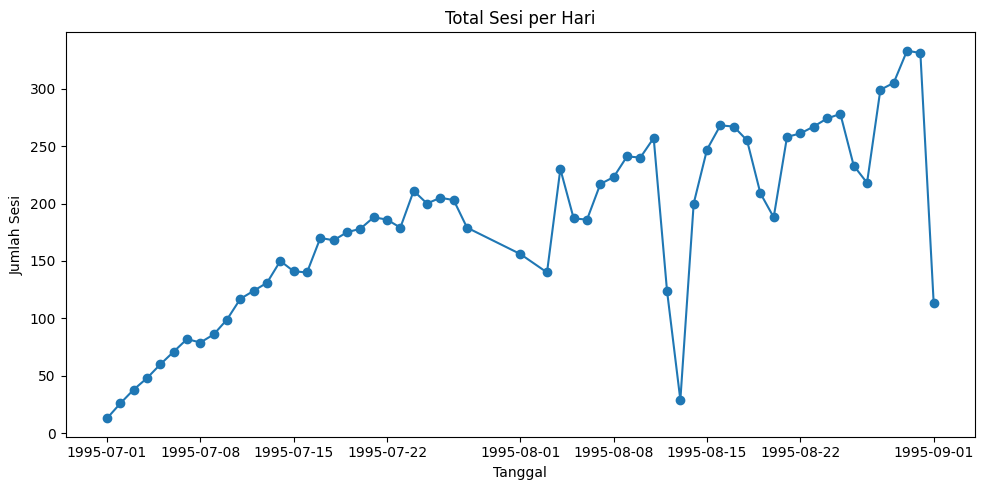

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Attempt to load the session data file
file_name = "/content/drive/MyDrive/PPW/webusage/real_session_30min_NASA.csv"

try:
    df = pd.read_csv(file_name, parse_dates=["datetime_readable"])
except Exception as e:
    print("Gagal memuat file:", e)
    print("Pastikan file 'real_session_30min_NASA.csv' sudah di-upload ke folder kerja.")
    raise

# =============== 2. TOTAL SESI PER HARI ===============
df["date"] = df["datetime_readable"].dt.date
sessions_per_day = df.groupby("date")["REAL_SESSION"].nunique()

plt.figure(figsize=(10,5))
sessions_per_day.plot(kind="line", marker="o")
plt.title("Total Sesi per Hari")
plt.xlabel("Tanggal")
plt.ylabel("Jumlah Sesi")
plt.tight_layout()
plt.show()


